<a href="https://colab.research.google.com/github/quinterogilalejandro-wq/Percepci-n-Computacional-/blob/main/Copia_de_Percepci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sube tus imagenes (pueden ser varias)...


Saving wp6588064.jpg to wp6588064.jpg
Cargando modelo YOLO...
Modelo listo

Procesando: images (1).jpg

image 1/1 /content/imagenes/images (1).jpg: 448x640 1 teddy bear, 173.2ms
Speed: 5.8ms preprocess, 173.2ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)
  Personas: 0 -> []
  Animales: 0 -> []


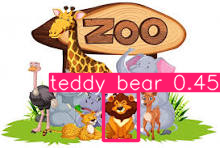


Procesando: 153654 (1).jpg

image 1/1 /content/imagenes/153654 (1).jpg: 640x640 1 bird, 2 cats, 2 dogs, 2 cows, 1 elephant, 2 bears, 2 giraffes, 1 cake, 250.8ms
Speed: 7.3ms preprocess, 250.8ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
  Personas: 0 -> []
  Animales: 9 -> ['giraffe(0.94)', 'elephant(0.92)', 'cat(0.82)', 'dog(0.81)', 'giraffe(0.73)', 'bear(0.64)', 'bear(0.63)', 'bird(0.49)', 'cat(0.43)']


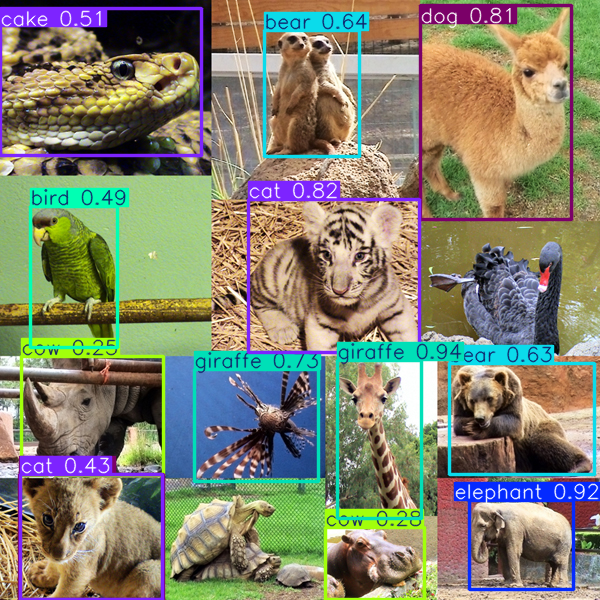


Procesando: wp6588064.jpg

image 1/1 /content/imagenes/wp6588064.jpg: 384x640 1 potted plant, 1 teddy bear, 232.8ms
Speed: 4.3ms preprocess, 232.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
  Personas: 0 -> []
  Animales: 0 -> []


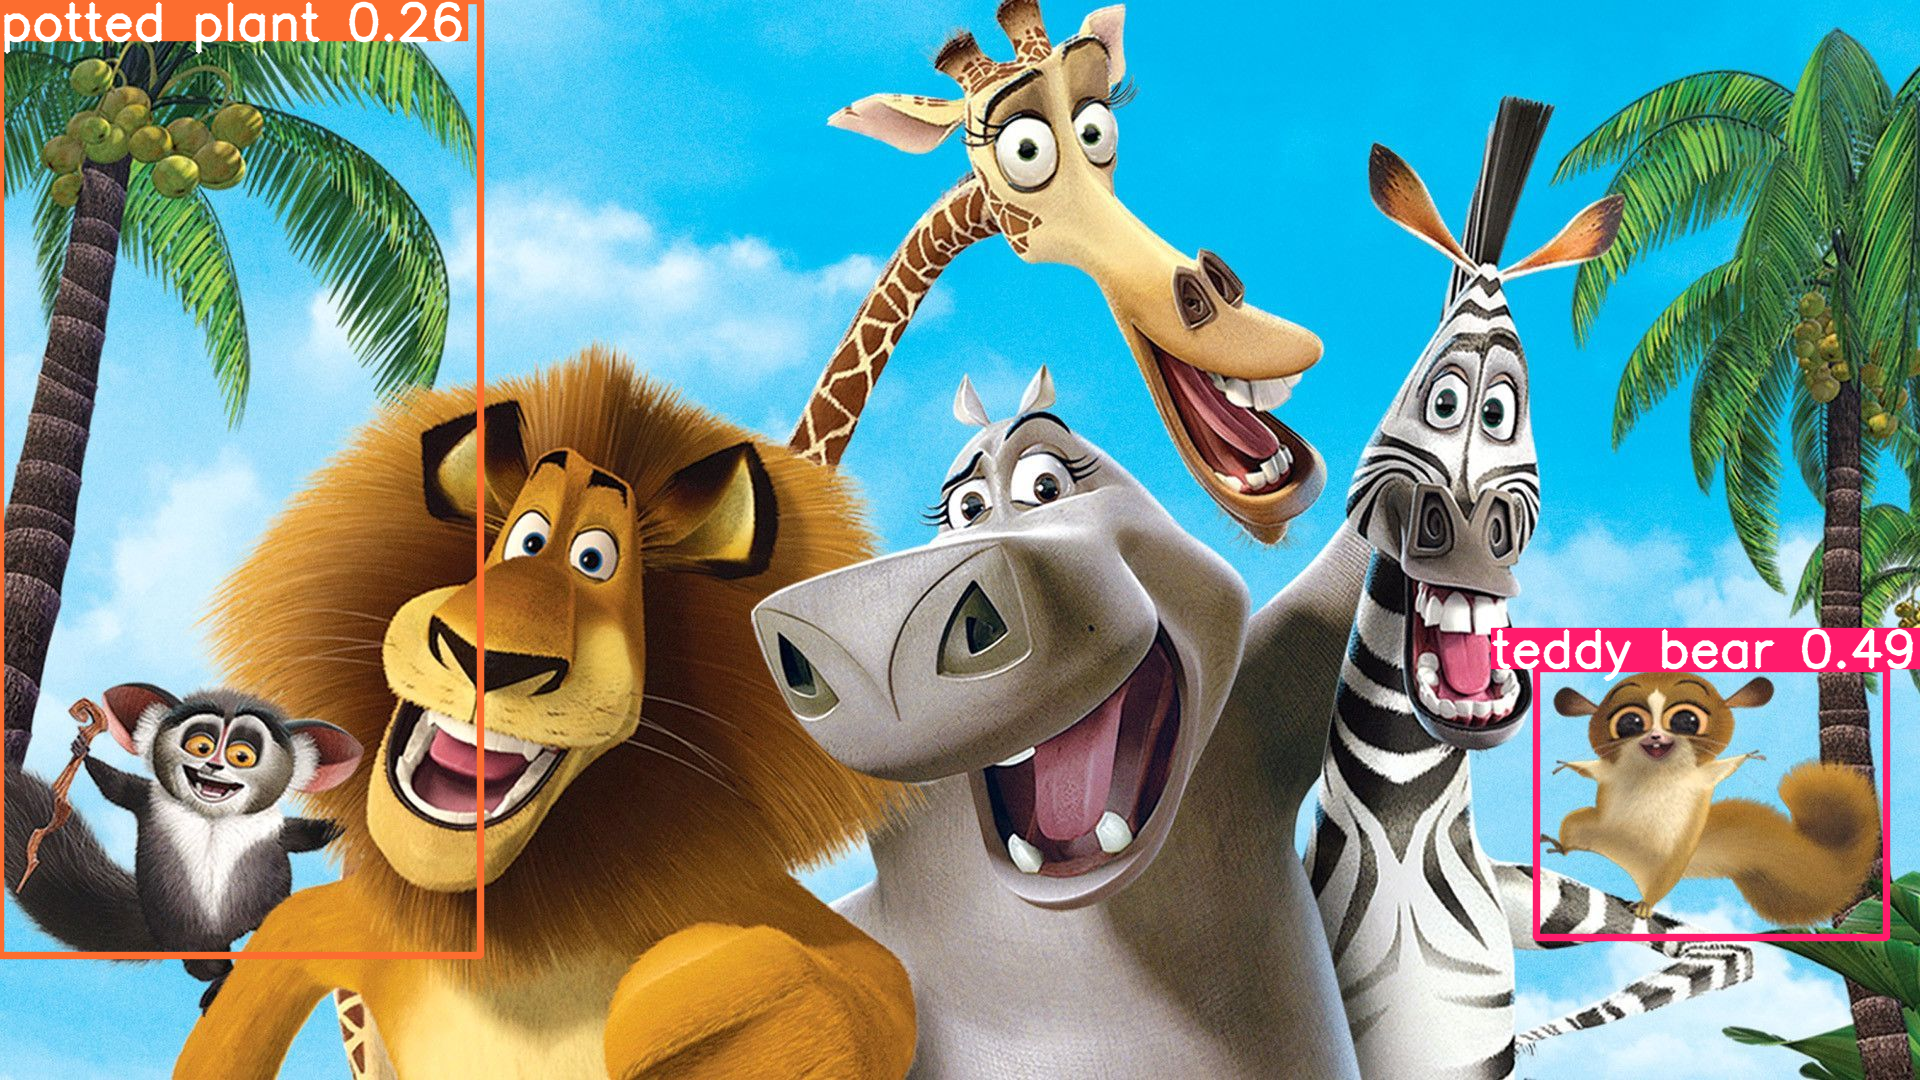


Procesando: 153654.jpg

image 1/1 /content/imagenes/153654.jpg: 640x640 1 bird, 2 cats, 2 dogs, 2 cows, 1 elephant, 2 bears, 2 giraffes, 1 cake, 423.7ms
Speed: 4.5ms preprocess, 423.7ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)
  Personas: 0 -> []
  Animales: 9 -> ['giraffe(0.94)', 'elephant(0.92)', 'cat(0.82)', 'dog(0.81)', 'giraffe(0.73)', 'bear(0.64)', 'bear(0.63)', 'bird(0.49)', 'cat(0.43)']


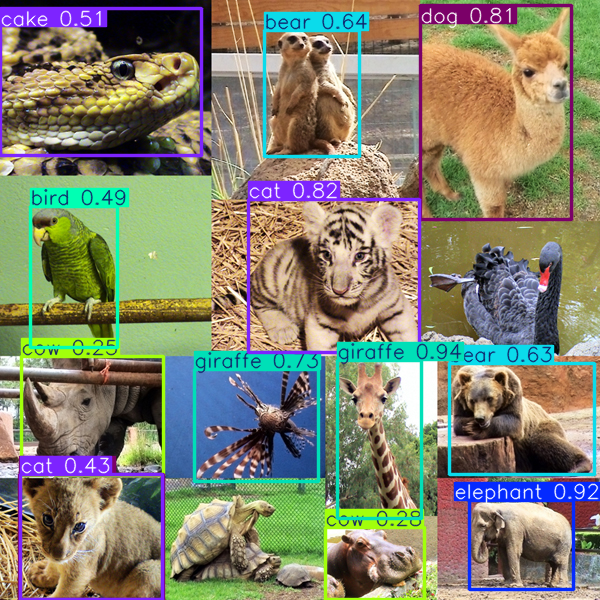


PROCESO FINALIZADO
Archivo generado: resultados_deteccion.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# DETECCION DE ANIMALES Y PERSONAS
# ============================================

# --------------------------------------------
# 1 - INSTALACION DE DEPENDENCIAS
# --------------------------------------------
import sys

try:
    from ultralytics import YOLO
    import cv2
except:
    print("Instalando dependencias...")
    import subprocess
    subprocess.run(["pip", "install", "-q", "ultralytics", "opencv-python"])
    from ultralytics import YOLO
    import cv2

import os
import csv
from datetime import datetime

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    from google.colab import files
    from google.colab.patches import cv2_imshow

# --------------------------------------------
# 2 - SUBIR IMAGENES (solo en Colab)
# --------------------------------------------
if EN_COLAB:
    print("Sube tus imagenes (pueden ser varias)...")
    uploaded = files.upload()

    os.makedirs("imagenes", exist_ok=True)

    for nombre in uploaded.keys():
        with open(os.path.join("imagenes", nombre), "wb") as f:
            f.write(uploaded[nombre])

# --------------------------------------------
# 3 - CONFIGURACION
# --------------------------------------------
CARPETA_IMAGENES = "imagenes"
ARCHIVO_SALIDA   = "resultados_deteccion.csv"

# Clases COCO
CLASES_PERSONAS = {0: "person"}

CLASES_ANIMALES = {
    14: "bird",
    15: "cat",
    16: "dog",
    17: "horse",
    18: "sheep",
    19: "cow",
    20: "elephant",
    21: "bear",
    22: "zebra",
    23: "giraffe"
}

CONFIANZA_MINIMA = 0.4

# --------------------------------------------
# 4 - VALIDAR CARPETA Y CARGAR MODELO
# --------------------------------------------
if not os.path.exists(CARPETA_IMAGENES):
    raise Exception("No existe la carpeta: " + CARPETA_IMAGENES)

print("Cargando modelo YOLO...")
model = YOLO("yolov8n.pt")
print("Modelo listo")

# --------------------------------------------
# 5 - PROCESAMIENTO DE IMAGENES
# --------------------------------------------
resultados = []

for archivo in os.listdir(CARPETA_IMAGENES):

    ruta = os.path.join(CARPETA_IMAGENES, archivo)

    if not archivo.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    print("\nProcesando: " + archivo)

    results = model(ruta)

    conteo_personas = 0
    conteo_animales = 0
    detalle_personas = []
    detalle_animales = []

    for r in results:

        if r.boxes is None:
            continue

        for box in r.boxes:

            cls  = int(box.cls[0].item())
            conf = float(box.conf[0].item())

            if conf < CONFIANZA_MINIMA:
                continue

            if cls in CLASES_PERSONAS:
                conteo_personas += 1
                detalle_personas.append("person(" + str(round(conf, 2)) + ")")

            elif cls in CLASES_ANIMALES:
                conteo_animales += 1
                nombre = CLASES_ANIMALES[cls]
                detalle_animales.append(nombre + "(" + str(round(conf, 2)) + ")")

    print("  Personas: " + str(conteo_personas) + " -> " + str(detalle_personas))
    print("  Animales: " + str(conteo_animales) + " -> " + str(detalle_animales))

    resultados.append([
        archivo,
        conteo_personas,
        ", ".join(detalle_personas) if detalle_personas else "ninguna",
        conteo_animales,
        ", ".join(detalle_animales) if detalle_animales else "ninguno",
        datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    ])

    # ----------------------------------------
    # VISUALIZAR RESULTADO
    # ----------------------------------------
    for r in results:
        img_resultado = r.plot()

        if EN_COLAB:
            cv2_imshow(img_resultado)
        else:
            cv2.imshow("Resultado", img_resultado)
            cv2.waitKey(500)

# --------------------------------------------
# 6 - GUARDAR CSV
# --------------------------------------------
with open(ARCHIVO_SALIDA, mode='w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow([
        "Imagen",
        "Cantidad_Personas",
        "Detalle_Personas",
        "Cantidad_Animales",
        "Detalle_Animales",
        "Fecha_Procesamiento"
    ])
    writer.writerows(resultados)

print("\n====================================")
print("PROCESO FINALIZADO")
print("Archivo generado: " + ARCHIVO_SALIDA)

# --------------------------------------------
# 7 - DESCARGAR RESULTADOS (solo Colab)
# --------------------------------------------
if EN_COLAB:
    files.download(ARCHIVO_SALIDA)

# --------------------------------------------
# 8 - LIMPIAR VENTANAS (solo local)
# --------------------------------------------
if not EN_COLAB:
    cv2.destroyAllWindows()